# Manuelle Einzelwand-Segmentierung (7ch, 5-Modell-Mean-Softmax-Ensemble)

Eigenstaendiger, manuell steuerbarer Durchlauf fuer **eine** Wand: DEM + Ortho rein,
Normalmaps und Klassenraster raus. Fuehrt bestehende Bausteine des Repos zusammen
(`amg_pipeline.segment`, `amg_pipeline.confidence`) und loest die Normalmap-Erzeugung
aus `01_image_preparation_for_ML/image_preparation_pipeline.ipynb` heraus, weil sie
nicht in `amg_pipeline` liegt.

**Ausfuehrungsumgebung:** Windows-Maschine mit CUDA-GPU und den trainierten
Checkpoints. Alle Pfade im Konfigurationsblock sind Windows-Pfade.

---

## Wichtig: H_Bf_1-4 gehoert zu den TRAININGSDATEN

Die Testwaende des Papers sind `H_Bf_5` (Wall 1), `K_Bf_13a` (Wall 2), `K_Bf_22` (Wall 3)
und `Kaunos_Isodom` (Wall 4). **H_Bf_1-4 war Teil des Trainingssatzes.**

Ein Vergleich von Segmentierung und Ground Truth auf dieser Wand misst also **Fit,
nicht Generalisierung**. Zahlen aus diesem Notebook sind Anschauungs- und
Arbeitsmaterial und duerfen nicht neben den Paper-Metriken stehen oder als
Evaluationsergebnis zitiert werden. Die kanonischen Zahlen liegen ausschliesslich in
`experiments/v2_baseline_ens/manifest.csv` und den zugehoerigen Metrik-CSVs.

---

## Ablauf

1. DEM (GeoTIFF) und Orthomosaik (PNG + .pgw) einlesen, Dimensionen und Transform pruefen
2. Zwei Normalmaps erzeugen (beide `eps = 0.001`):
   * `normalmap_ransac.tif` — **mit** RANSAC-Kippkorrektur, die Trainingsvariante, die einzige, mit der segmentiert wird
   * `OUTDATED_no-ransac_normalmap.tif` — **ohne** Kippkorrektur, nur zum visuellen Vergleich
3. Segmentierung mit dem Paper-Modell (7 Kanaele) als 5-Modell-Mean-Softmax-Ensemble
4. Klassenraster, Uebersichtsabbildung und Provenienz-Datei schreiben

## Konventionen und Fallstricke, die hier eingehalten werden

**Kanalreihenfolge.** `segment._build_wall_stack` liest das Ortho mit
`cv2.imread(..., IMREAD_UNCHANGED)` und die Normalmap mit `cv2.imread(..., IMREAD_COLOR)`.
OpenCV liefert in beiden Faellen BGR(A). Die Normalmap-PNGs der Praeparationspipeline
werden von PIL als RGB in der Reihenfolge `(nx, ny, nz)` geschrieben — nach dem
cv2-Rueckweg steht dort also `(nz, ny, nx)`. Der 7-Kanal-Stack des Trainings ist damit
faktisch:

```
[B, G, R, A, nz, ny, nx]
```

Dieses Notebook baut den Stack genau so: das Ortho wird mit denselben cv2-Aufrufen
gelesen, die Normalmap wird **nicht** ueber cv2 aus dem GeoTIFF zurueckgelesen (die
Band-Interpretation von GDAL/OpenCV bei TIFF ist als Fundament fuer Paper-Treue zu
unsicher), sondern das encodierte uint8-Array wird direkt im Speicher gehalten und
explizit auf `(nz, ny, nx)` umsortiert. Bitgleich zum Trainingspfad, ohne implizite
Annahme.

**Reihenfolge Ensemble vor Merge.** Pro Fenster werden erst die Softmax-Ausgaben der
5 Modelle gemittelt, danach laeuft der center-weighted Merge ueber die Fenster —
genau wie in `amg_pipeline/ensemble.py`. Nicht vertauschen.

**RANSAC auf Stichprobe.** Die Originalfunktion zaehlt Inlier ueber alle Wandpixel.
Bei 751 Mio. Pixeln × 100 Hypothesen ist das nicht rechenbar. Es wird eine
Zufallsstichprobe von `RANSAC_SAMPLE_PIXELS` Wandpixeln gezogen (fester Seed) und
`ransac_mean_normal` unveraendert darauf angewendet. Bei 5 Mio. Stichprobenpixeln
landet `n_samples` bei 5000, also exakt auf dem Cap (`RANSAC_SAMPLE_RATIO = 1000`,
`RANSAC_MAX_SAMPLES = 5000`), den die Originalfunktion bei jeder Wand ohnehin
erreicht. Die Abweichung ist in der Provenienz-Datei dokumentiert.

**Nodata im Gradienten.** Die publizierte Pipeline maskiert das DEM **nicht** vor
`np.gradient`; Nodata-Werte gehen an den Raendern gueltiger Bereiche in die Ableitung
ein und werden erst danach ueber die Maske genullt. Das wird hier bewusst
unveraendert uebernommen. Die Maske kommt aus `src.dataset_mask() > 0`, nie aus einem
hartkodierten Nodata-Wert.

**`experiments/` ist reine Lesequelle.** Es werden ausschliesslich die Checkpoints
gelesen; geschrieben wird nur nach `OUT_DIR`.

**Zwei bekannte Eigenheiten in `segment.py`** (hier nicht angefasst, ohne Folgen fuer
dieses Notebook): der OOM-Fallback in `_segment_window` ruft sich mit zu wenigen
Argumenten auf, und `if device == "cuda"` vergleicht ein `torch.device` mit einem
String und ist deshalb nie wahr. Das Leeren des CUDA-Caches uebernimmt hier die
eigene Schleife.

In [1]:
# =============================================================================
# KONFIGURATIONSBLOCK — hier und nur hier wird pro Wand angepasst.
# =============================================================================
from pathlib import Path

# --- Eingaben (Windows-Pfade) ------------------------------------------------
DEM_PATH   = Path(r"C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\dem\H_Bf_1-4_DEM.tif")
ORTHO_PATH = Path(r"C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\ortho\H_Bf_1-4_ortho.png")   # .pgw muss danebenliegen
OUT_DIR    = Path(r"C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\segmentation")

WALL_NAME = "H_Bf_1-4"          # nur fuer Ausgaben und Provenienz

# --- Repo und Checkpoints ----------------------------------------------------
REPO_ROOT           = Path(r"C:\Users\admin\Documents\GitHub\AppearanceMeetsGeometry")
EXPERIMENTS_ROOT    = REPO_ROOT / "experiments"
SOURCE_EXPERIMENT   = "v2_yaw_correction-epsV1"
N_RUNS              = 5
CHECKPOINT_FILENAME = "model.pth"       # Final-Epoch. NICHT model_best.pth.
CHANNELS            = 7

# --- Normalmap (Paper-Parameter, nicht aendern) ------------------------------
NZ_MODE   = "fixed_eps"
NZ_EPS    = 0.001
NZ_FACTOR = 4.0                          # nur fuer NZ_MODE='pixel_size_scaled' relevant

RANSAC_N_HYPOTHESES   = 100
RANSAC_MIN_SAMPLES    = 500
RANSAC_MAX_SAMPLES    = 5000
RANSAC_SAMPLE_RATIO   = 1000
RANSAC_THRESHOLD_DEG  = 20.0
RANSAC_REFINE_ITERS   = 5
RANSAC_SEED           = 42
RANSAC_SAMPLE_PIXELS  = 5_000_000        # Groesse der Wandpixel-Stichprobe fuer den Fit

# --- Inferenz (Paper-Parameter, nicht aendern) -------------------------------
WINDOW_SIZE = (1280, 1280)
STRIDE      = 960
MODEL_SIZE  = (512, 512)

# Fenster, die vollstaendig im Hintergrund liegen (Alpha ueberall 0), ueberspringen.
# Diese Pixel erhalten dadurch Gewicht 0 und werden beim argmax zu Background (0).
# Abweichung vom Paper-Pfad, spart bei langen Waenden viel Rechenzeit.
SKIP_EMPTY_WINDOWS = True

# --- Ausschnitt zum schnellen Testen -----------------------------------------
# None = ganze Wand. Sonst (x0, y0, x1, y1) in Pixelkoordinaten des Vollrasters.
# Der Transform wird fuer den Ausschnitt korrekt mitgefuehrt.
CROP = None
# CROP = (20000, 0, 26000, 9627)

# --- Speicher / Blockgroessen -------------------------------------------------
BLOCK_ROWS          = 1024      # Zeilenbloecke fuer DEM/Gradient/Ausgabe
ACCUMULATOR_MODE    = "auto"    # "auto" | "ram" | "memmap"
ACCUM_RAM_BUDGET_GB = 48.0      # ab hier weicht "auto" auf np.memmap aus

# --- Ausgaben ----------------------------------------------------------------
SAVE_NORMALMAP_PNG        = True    # zusaetzlich zur .tif, drop-in fuer die bestehende Pipeline
SAVE_SEGMENTATION_RAW_PNG = True    # farbiges RAW-PNG in Repo-Konvention (CLASS_COLORS_RGB)
SAVE_PROBS_FLOAT16        = True    # gemittelte Klassenwahrscheinlichkeiten, HWC float16 .npy
OVERVIEW_MAX_WIDTH        = 6000    # Zielbreite der Uebersichtsabbildung

# --- Rechengeraet -------------------------------------------------------------
DEVICE_PREFERENCE = "auto"      # "auto" | "cuda" | "mps" | "cpu"

# --- Toleranz beim Abgleich der Georeferenz ----------------------------------
TRANSFORM_TOL = 1e-6            # Meter

In [2]:
import os

# Muss VOR dem cv2-Import gesetzt sein. OpenCV begrenzt die Bildgroesse beim Lesen
# (Default 2**30 px). Diese Wand liegt mit 751 Mpx darunter, der Puffer schadet nicht.
os.environ.setdefault("OPENCV_IO_MAX_IMAGE_PIXELS", str(2**31))

import sys
import gc
import math
import time
import hashlib
import platform
import datetime

import numpy as np
import cv2
import rasterio
from rasterio.windows import Window
from rasterio.windows import transform as window_transform
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

Image.MAX_IMAGE_PIXELS = None

# --- Repo-Anbindung ----------------------------------------------------------
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from amg_pipeline.segment import (_load_model, _segment_window,
                                  create_sliding_windows)
from amg_pipeline.confidence import _center_weight
from amg_pipeline.data import CLASS_COLORS_RGB, CLASS_NAMES

# --- Rechengeraet -------------------------------------------------------------
def _pick_device(preference):
    if preference != "auto":
        return torch.device(preference)
    if torch.cuda.is_available():
        return torch.device("cuda")
    mps = getattr(torch.backends, "mps", None)
    if mps is not None and mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = _pick_device(DEVICE_PREFERENCE)

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python     :", platform.python_version(), "|", platform.platform())
print("torch      :", torch.__version__)
print("OpenCV     :", cv2.__version__)
print("rasterio   :", rasterio.__version__)
print("Geraet     :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU        :", torch.cuda.get_device_name(0))
print("Ausgaben   :", OUT_DIR)

_run_started = datetime.datetime.now()
_timings = {}

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python     : 3.11.9 | Windows-10-10.0.26200-SP0
torch      : 2.9.0.dev20250721+cu128
OpenCV     : 4.12.0
rasterio   : 1.4.3
Geraet     : cuda
GPU        : NVIDIA GeForce RTX 5080
Ausgaben   : C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\segmentation


## Gewaehlte Speicherstrategie (und warum)

Vorgabe war: `np.memmap`, `float16` oder vertikale Streifen. Gewaehlt ist **ein globaler
Akkumulator im RAM, gefuellt in einer streamenden Fensterschleife**. Begruendung:

* Die bestehende `segment()`-Funktion sammelt erst alle Fenster in `windows_data` und
  ruft danach `combine_center_weighted` auf. Genau dieser Teil faellt hier weg: jedes
  Fenster wird sofort ueber alle 5 Modelle gerechnet, gemittelt, in den Akkumulator
  eingerechnet und verworfen. Die 22 GiB Fensterliste entstehen nie. Das Muster ist
  nicht neu erfunden, sondern das von `amg_pipeline/confidence.py::_wall_probabilities`,
  das dort bereits als numerisch identisch zu `combine_center_weighted` dokumentiert ist.
* **Gegen vertikale Streifen** spricht, dass benachbarte Fenster sich um
  `window - stride = 320 px` ueberlappen. Streifen waeren also nie unabhaengig: Pixel im
  Randbereich bekaemen Beitraege aus Fenstern beider Streifen, ein streifenweises
  `argmax` waere dort schlicht falsch. Korrekt loesbar nur ueber doppelt gerechnete
  Randfenster oder ueber genau den globalen Akkumulator, den man vermeiden wollte.
* **Der globale Akkumulator passt.** Bei 78.073 x 9.627 px sind das
  `class_scores` 12,0 GB (float32, 4 Klassen) plus `weights` 2,8 GB. Dazu Ortho 3,0 GB
  und encodierte Normalmap 2,25 GB, die im RAM gehalten werden, damit der 7-Kanal-Stack
  pro Fenster ohne Plattenzugriff entsteht (11 MB pro Fenster statt 4,9 GB am Stueck).
  Spitze rund 20 GB bei 128 GB verfuegbarem RAM.
* `float16` wird fuer den Akkumulator **nicht** benutzt: die aufsummierten
  gewichteten Wahrscheinlichkeiten laufen ueber viele Fenster, float16 haette hier zu
  wenig Mantisse. Float16 kommt nur bei der optionalen Ausgabe der fertigen
  Wahrscheinlichkeiten zum Einsatz — dieselbe Konvention wie in `confidence.py`.
* `ACCUMULATOR_MODE = "auto"` weicht automatisch auf `np.memmap` aus, wenn der
  geschaetzte Bedarf `ACCUM_RAM_BUDGET_GB` uebersteigt (etwa bei noch groesseren Waenden).

Die **Normalmap-Erzeugung** laeuft blockweise ueber Zeilenbloecke mit einer Zeile Halo.
`np.gradient` nutzt im Inneren zentrale Differenzen und an den Raendern einseitige;
mit einem Halo von einer Zeile ist das Blockergebnis im Inneren deshalb bitgleich zur
Vollbildrechnung, und an den echten Bildraendern greift korrekt die einseitige Variante.
Das DEM wird pro Block in float64 gerechnet (wie im Original) und als float32
zwischengespeichert; die Rotation laeuft wieder in float64. Der Quantisierungsschritt
der uint8-Kodierung ist 1/255, die float32-Zwischenspeicherung liegt vier
Groessenordnungen darunter.

In [3]:
def window_positions(height, width, window_size, stride):
    """Positionen des Schiebefensters.

    Spiegelt segment.create_sliding_windows exakt, materialisiert die Fenster aber
    NICHT (902 Fenster x 1280x1280x7 Byte waeren rund 10 GB). Der Selbsttest unten
    prueft die Uebereinstimmung gegen die Repo-Funktion.
    """
    pos = []
    for y in range(0, height, stride):
        for x in range(0, width, stride):
            y_end = min(y + window_size[0], height)
            x_end = min(x + window_size[1], width)
            y_start = max(0, y_end - window_size[0])
            x_start = max(0, x_end - window_size[1])
            pos.append((y_start, x_start, y_end, x_end))
    return pos


_dummy = np.zeros((2600, 4100, 1), dtype=np.uint8)
_, _ref_positions = create_sliding_windows(_dummy, WINDOW_SIZE, STRIDE)
assert _ref_positions == window_positions(2600, 4100, WINDOW_SIZE, STRIDE), (
    "Fenstergitter weicht von segment.create_sliding_windows ab")
del _dummy, _ref_positions
print("Selbsttest ok: Fenstergitter identisch zu segment.create_sliding_windows")


def write_geotiff_uint8(path, arr, transform):
    """uint8-Raster als GeoTIFF schreiben: tiled, LZW, Transform erhalten, CRS weggelassen.

    Das DEM traegt intern ein falsches CRS (EPSG:4978, geozentrisch, LENGTHUNIT
    'unknown'). Es wird deshalb bewusst kein CRS geschrieben; der Transform bleibt.
    """
    count = 1 if arr.ndim == 2 else arr.shape[2]
    profile = {
        "driver": "GTiff",
        "height": arr.shape[0],
        "width": arr.shape[1],
        "count": count,
        "dtype": "uint8",
        "transform": transform,
        "crs": None,
        "tiled": True,
        "blockxsize": 512,
        "blockysize": 512,
        "compress": "LZW",
        "BIGTIFF": "IF_SAFER",
    }
    if count == 3:
        profile["photometric"] = "RGB"
    with rasterio.open(path, "w", **profile) as dst:
        if count == 1:
            dst.write(arr, 1)
        else:
            for b in range(count):
                dst.write(arr[:, :, b], b + 1)
    print("geschrieben:", path)


def sha256_of(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def gb(n_bytes):
    return n_bytes / 1e9

Selbsttest ok: Fenstergitter identisch zu segment.create_sliding_windows


## Schritt 1 — DEM und Orthomosaik einlesen

Die Georeferenz wird mit rasterio gelesen, **nicht** durch Parsen der `.pgw`: Weltdateien
geben die Pixelmitte an, GDAL die Pixelecke. Bei 1,79 mm Pixelgroesse waeren das 0,9 mm
Versatz.

Vor jeder Rechnung wird geprueft, dass DEM und Ortho identische Dimensionen **und**
identischen Transform tragen. Beides bricht hart ab — ein unbemerkter Versatz wuerde
sich still bis in die georeferenzierte Ausgabe fortpflanzen.

Das Ortho wird mit `cv2.imread(..., IMREAD_UNCHANGED)` gelesen, also BGRA, exakt wie im
Training. Achtung bei gesetztem `CROP`: cv2 kann PNG nur ganz lesen, der Ausschnitt wird
erst danach geschnitten. Der Testlauf spart also Inferenzzeit, nicht Ladezeit.

In [4]:
_t0 = time.time()

for p in (DEM_PATH, ORTHO_PATH):
    if not p.exists():
        raise FileNotFoundError(f"Eingabedatei fehlt: {p}")

with rasterio.open(DEM_PATH) as src:
    dem_shape     = (src.height, src.width)
    dem_transform = src.transform
    dem_crs       = src.crs
    dem_nodata    = src.nodata
    dem_dtype     = src.dtypes[0]

with rasterio.open(ORTHO_PATH) as src:
    ortho_shape     = (src.height, src.width)
    ortho_transform = src.transform

print("DEM   :", dem_shape, dem_dtype, "| nodata:", dem_nodata)
print("        CRS im DEM:", dem_crs, " (wird bewusst NICHT weitergereicht)")
print("        transform:", tuple(round(v, 12) for v in dem_transform[:6]))
print("Ortho :", ortho_shape)
print("        transform:", tuple(round(v, 12) for v in ortho_transform[:6]))

if ortho_transform == rasterio.Affine.identity():
    raise RuntimeError(
        "Das Ortho traegt keine Georeferenz (Transform ist die Identitaet). "
        "GDAL hat die Weltdatei nicht gefunden: sie muss denselben Basisnamen wie das "
        "PNG tragen und auf .pgw oder .wld enden.")

if dem_shape != ortho_shape:
    raise ValueError(f"Dimensionen weichen ab: DEM {dem_shape} vs Ortho {ortho_shape}")

_delta = max(abs(a - b) for a, b in zip(dem_transform[:6], ortho_transform[:6]))
if _delta > TRANSFORM_TOL:
    raise ValueError(
        f"Transform von DEM und Ortho weichen ab (max. Abweichung {_delta:.3e} > "
        f"{TRANSFORM_TOL:.0e}).")
print(f"Assertion ok: identische Dimensionen und Transform (max. Abweichung {_delta:.3e})")

# --- Ausschnitt ---------------------------------------------------------------
H_FULL, W_FULL = dem_shape
if CROP is None:
    CX0, CY0, CX1, CY1 = 0, 0, W_FULL, H_FULL
else:
    CX0, CY0, CX1, CY1 = CROP
    if not (0 <= CX0 < CX1 <= W_FULL and 0 <= CY0 < CY1 <= H_FULL):
        raise ValueError(f"CROP {CROP} liegt nicht im Raster {W_FULL}x{H_FULL}")

H, W = CY1 - CY0, CX1 - CX0
OUT_WINDOW    = Window(col_off=CX0, row_off=CY0, width=W, height=H)
OUT_TRANSFORM = window_transform(OUT_WINDOW, dem_transform)
PIXEL_SIZE_M  = abs(dem_transform.a)

print()
print(f"Bearbeitet: {W} x {H} px  ({W * H / 1e6:.1f} Mpx)  |  CROP = {CROP}")
print(f"Pixelgroesse: {PIXEL_SIZE_M * 1000:.5f} mm  |  Breite real {W * PIXEL_SIZE_M:.2f} m")
print("Transform der Ausgaben:", tuple(round(v, 12) for v in OUT_TRANSFORM[:6]))

# --- Ortho laden (cv2, damit die Kanalreihenfolge dem Training entspricht) ----
print()
print("lade Ortho mit cv2 ...")
_ortho_full = cv2.imread(str(ORTHO_PATH), cv2.IMREAD_UNCHANGED)
if _ortho_full is None:
    raise RuntimeError(f"cv2 konnte das Ortho nicht lesen: {ORTHO_PATH}")
if _ortho_full.ndim != 3:
    raise ValueError(f"Ortho hat unerwartete Form {_ortho_full.shape}, erwartet HxWx3 oder HxWx4")
if _ortho_full.dtype != np.uint8:
    raise ValueError(f"Ortho hat dtype {_ortho_full.dtype}, erwartet uint8")
if _ortho_full.shape[:2] != (H_FULL, W_FULL):
    raise ValueError(f"cv2 liest {_ortho_full.shape[:2]}, rasterio meldet {(H_FULL, W_FULL)}")

if _ortho_full.shape[2] == 3:
    # identisch zu segment._build_wall_stack: fehlender Alphakanal wird auf 255 gesetzt
    _alpha = np.full((_ortho_full.shape[0], _ortho_full.shape[1], 1), 255, dtype=np.uint8)
    _ortho_full = np.concatenate([_ortho_full, _alpha], axis=2)
    del _alpha
    print("  Hinweis: Ortho ohne Alphakanal, Alpha auf 255 gesetzt (wie in _build_wall_stack)")

if CROP is None:
    ortho = _ortho_full
else:
    ortho = np.ascontiguousarray(_ortho_full[CY0:CY1, CX0:CX1])
    del _ortho_full
    gc.collect()

print(f"Ortho im Speicher: {ortho.shape} {ortho.dtype}  ({gb(ortho.nbytes):.2f} GB)  [B, G, R, A]")
_timings["01_einlesen"] = time.time() - _t0
print(f"Dauer: {_timings['01_einlesen']:.1f} s")

DEM   : (9627, 78073) float32 | nodata: -32767.0
        CRS im DEM: EPSG:4978  (wird bewusst NICHT weitergereicht)
        transform: (0.00179119, 0.0, -67.063330432751, 0.0, -0.00179119, 7.800889875233)
Ortho : (9627, 78073)
        transform: (0.00179119, 0.0, -67.063330432751, 0.0, -0.00179119, 7.800889875233)
Assertion ok: identische Dimensionen und Transform (max. Abweichung 0.000e+00)

Bearbeitet: 78073 x 9627 px  (751.6 Mpx)  |  CROP = None
Pixelgroesse: 1.79119 mm  |  Breite real 139.84 m
Transform der Ausgaben: (0.00179119, 0.0, -67.063330432751, 0.0, -0.00179119, 7.800889875233)

lade Ortho mit cv2 ...
Ortho im Speicher: (9627, 78073, 4) uint8  (3.01 GB)  [B, G, R, A]
Dauer: 7.8 s


## Schritt 2 — Normalmaps

Die folgenden Funktionen sind **unveraendert** aus
`01_image_preparation_for_ML/image_preparation_pipeline.ipynb` (Zelle 5) uebernommen:
`resolve_nz`, `compute_normals_mikkelsen`, `normals_to_rgb`, `angle_to_normal`,
`ransac_mean_normal`, `rotation_matrix_to_z`, `rotate_normals`. Nur der Aufruf ist neu
(blockweise statt am Stueck, RANSAC-Fit auf einer Stichprobe).

Verbindliche Parameter: `n = (-dz/dx, +dz/dy, nz)` mit anschliessender Normalisierung,
`NZ_MODE = fixed_eps`, `NZ_EPS = 0.001`, Nodata-Maske ueber `src.dataset_mask() > 0`.
Kippkorrektur: RANSAC mit LO-Refinement auf den Normalen, Rodrigues-Rotation der
mittleren Wandnormalen auf (0, 0, 1).

In [5]:
# =============================================================================
# Unveraendert aus 01_image_preparation_for_ML/image_preparation_pipeline.ipynb
# =============================================================================

def resolve_nz(pixel_size_m):
    """Return the scalar nz value for the configured NZ_MODE."""
    if NZ_MODE == "pixel_size":
        return pixel_size_m
    elif NZ_MODE == "fixed_eps":
        return NZ_EPS
    elif NZ_MODE == "pixel_size_scaled":
        return pixel_size_m / NZ_FACTOR
    else:
        raise ValueError(
            f"Unknown NZ_MODE {NZ_MODE!r}; "
            "expected 'pixel_size' | 'fixed_eps' | 'pixel_size_scaled'")


def compute_normals_mikkelsen(dem, mask, nz_value):
    """Mikkelsen-convention tangent-space normal map.
    Formula: n = (-dzdx, +dzdy, nz_value) / ||.||
    """
    dzdx = np.gradient(dem, axis=1)
    dzdy = np.gradient(dem, axis=0)
    nx = -dzdx
    ny = dzdy   # Y-flip for OpenGL convention
    nz = nz_value * np.ones_like(dem)
    norm = np.sqrt(nx**2 + ny**2 + nz**2)
    nx /= norm; ny /= norm; nz /= norm
    n = np.stack((nx, ny, nz), axis=-1)
    n[~mask] = 0
    return n


def normals_to_rgb(n, mask):
    """Encode normals as 8-bit RGB: (v + 1) / 2 * 255. Background stays black."""
    rgb = np.zeros((*n.shape[:2], 3), dtype=np.uint8)
    rgb[..., 0] = np.clip((n[..., 0] * 0.5 + 0.5) * 255, 0, 255)
    rgb[..., 1] = np.clip((n[..., 1] * 0.5 + 0.5) * 255, 0, 255)
    rgb[..., 2] = np.clip((n[..., 2] * 0.5 + 0.5) * 255, 0, 255)
    rgb[~mask] = 0
    return rgb


def angle_to_normal(normals, ref):
    """Angle (radians) between each pixel normal and a reference normal."""
    dot = np.clip(np.sum(normals * ref, axis=-1), -1.0, 1.0)
    return np.arccos(dot)


def ransac_mean_normal(normals, mask,
                       n_hypotheses=RANSAC_N_HYPOTHESES,
                       min_samples=RANSAC_MIN_SAMPLES, max_samples=RANSAC_MAX_SAMPLES,
                       sample_ratio=RANSAC_SAMPLE_RATIO,
                       threshold_deg=RANSAC_THRESHOLD_DEG,
                       refine_iters=RANSAC_REFINE_ITERS,
                       seed=42):
    """RANSAC with fixed angular threshold + LO-RANSAC refinement."""
    rng = np.random.default_rng(seed)
    wall_normals = normals[mask]
    n_wall = wall_normals.shape[0]
    n_samples = int(np.clip(n_wall // sample_ratio, min_samples, max_samples))
    threshold_rad = np.radians(threshold_deg)

    best_count = -1
    best_candidate = None

    for _ in range(n_hypotheses):
        idx = rng.choice(n_wall, size=n_samples, replace=False)
        sample = wall_normals[idx]
        cand = sample.mean(axis=0)
        norm = np.linalg.norm(cand)
        if norm < 1e-9:
            continue
        cand = cand / norm
        angles = angle_to_normal(wall_normals, cand)
        n_inliers = int((angles < threshold_rad).sum())
        if n_inliers > best_count:
            best_count = n_inliers
            best_candidate = cand

    if best_candidate is None:
        raise RuntimeError("RANSAC found no valid hypothesis (all samples degenerate).")

    candidate = best_candidate
    for it in range(refine_iters):
        angles = angle_to_normal(wall_normals, candidate)
        inlier_idx = np.where(angles < threshold_rad)[0]
        if inlier_idx.size < 10:
            break
        new_candidate = wall_normals[inlier_idx].mean(axis=0)
        new_candidate /= np.linalg.norm(new_candidate)
        cos_change = np.clip(np.dot(candidate, new_candidate), -1, 1)
        delta_deg = np.degrees(np.arccos(cos_change))
        candidate = new_candidate
        if delta_deg < 0.01:
            break

    final_normal = candidate
    angles = angle_to_normal(wall_normals, final_normal)
    final_inlier_idx = np.where(angles < threshold_rad)[0]

    inlier_mask_full = np.zeros_like(mask, dtype=bool)
    wall_idx_flat = np.where(mask.ravel())[0]
    inlier_mask_full.ravel()[wall_idx_flat[final_inlier_idx]] = True

    diagnostics = {
        "n_wall": n_wall,
        "n_samples_per_hypothesis": n_samples,
        "threshold_deg": threshold_deg,
        "final_inlier_count": int(final_inlier_idx.size),
        "final_inlier_pct": 100.0 * final_inlier_idx.size / n_wall,
        "final_normal": final_normal,
    }
    return final_normal, inlier_mask_full, diagnostics


def rotation_matrix_to_z(src):
    """Minimal rotation matrix mapping src onto (0, 0, 1). Rodrigues formula."""
    src = src / np.linalg.norm(src)
    target = np.array([0.0, 0.0, 1.0])
    cos_theta = np.dot(src, target)
    if cos_theta > 1 - 1e-9:
        return np.eye(3)
    if cos_theta < -1 + 1e-9:
        axis = np.array([1.0, 0.0, 0.0]) if abs(src[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
        axis = axis - axis.dot(src) * src
        axis /= np.linalg.norm(axis)
        K = np.array([[0, -axis[2], axis[1]],
                      [axis[2], 0, -axis[0]],
                      [-axis[1], axis[0], 0]])
        return np.eye(3) + 2 * K @ K

    axis = np.cross(src, target)
    sin_theta = np.linalg.norm(axis)
    axis /= sin_theta
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    R = np.eye(3) + sin_theta * K + (1 - cos_theta) * (K @ K)
    return R


def rotate_normals(normals, mask, R):
    """Apply a 3x3 rotation to all normal vectors. Background stays (0,0,0)."""
    H_, W_, _ = normals.shape
    flat = normals.reshape(-1, 3)
    rotated = flat @ R.T
    rotated_3d = rotated.reshape(H_, W_, 3)
    rotated_3d[~mask] = 0
    return rotated_3d


print("Normalmap-Funktionen geladen (unveraendert aus der Praeparationspipeline)")

Normalmap-Funktionen geladen (unveraendert aus der Praeparationspipeline)


In [6]:
_t0 = time.time()
NZ_VALUE = resolve_nz(PIXEL_SIZE_M)
print(f"NZ_MODE={NZ_MODE!r}  ->  nz = {NZ_VALUE}")
print(f"Blockgroesse: {BLOCK_ROWS} Zeilen (+1 Zeile Halo fuer np.gradient)")
print(f"Puffer: normals float32 {gb(H * W * 3 * 4):.2f} GB, Maske {gb(H * W):.2f} GB")
print()

# --- 1) Wandmaske einlesen und Wandpixel zaehlen ------------------------------
wall_mask = np.empty((H, W), dtype=bool)
n_wall_total = 0
with rasterio.open(DEM_PATH) as src:
    for r0 in tqdm(range(0, H, BLOCK_ROWS), desc="Wandmaske"):
        r1 = min(H, r0 + BLOCK_ROWS)
        m = src.dataset_mask(window=Window(CX0, CY0 + r0, W, r1 - r0)) > 0
        wall_mask[r0:r1] = m
        n_wall_total += int(m.sum())

if n_wall_total == 0:
    raise RuntimeError("Die Wandmaske ist leer - dataset_mask() liefert nirgends gueltige Pixel.")

p_keep = min(1.0, RANSAC_SAMPLE_PIXELS / float(n_wall_total))
print(f"Wandpixel: {n_wall_total:,} von {H * W:,} ({100.0 * n_wall_total / (H * W):.1f} %)")
print(f"Stichprobe fuer den RANSAC-Fit: p_keep = {p_keep:.6f}")

# --- 2) Normalen blockweise berechnen, Stichprobe sammeln ---------------------
normals = np.empty((H, W, 3), dtype=np.float32)
rng_sample = np.random.default_rng(RANSAC_SEED)
sample_chunks = []

with rasterio.open(DEM_PATH) as src:
    for r0 in tqdm(range(0, H, BLOCK_ROWS), desc="Normalen (blockweise)"):
        r1 = min(H, r0 + BLOCK_ROWS)
        h0, h1 = max(0, r0 - 1), min(H, r1 + 1)          # eine Zeile Halo
        dem_blk = src.read(1, window=Window(CX0, CY0 + h0, W, h1 - h0)).astype(np.float64)
        n_blk = compute_normals_mikkelsen(dem_blk, wall_mask[h0:h1], NZ_VALUE)
        lo = r0 - h0
        n_core = n_blk[lo:lo + (r1 - r0)]
        normals[r0:r1] = n_core.astype(np.float32)

        sel = n_core[wall_mask[r0:r1]]
        if sel.size and p_keep < 1.0:
            sel = sel[rng_sample.random(sel.shape[0]) < p_keep]
        if sel.size:
            sample_chunks.append(np.ascontiguousarray(sel))
        del dem_blk, n_blk, n_core, sel

gc.collect()

# --- 3) RANSAC auf der Stichprobe ---------------------------------------------
sample = np.concatenate(sample_chunks, axis=0)
del sample_chunks
gc.collect()
print()
print(f"RANSAC-Fit auf {sample.shape[0]:,} Normalen ...")

sample_img  = sample.reshape(-1, 1, 3)
sample_mask = np.ones(sample_img.shape[:2], dtype=bool)
mean_normal, _inliers, ransac_diag = ransac_mean_normal(sample_img, sample_mask,
                                                        seed=RANSAC_SEED)
del sample, sample_img, sample_mask, _inliers
gc.collect()

deviation_deg = float(np.degrees(np.arccos(np.clip(mean_normal[2], -1, 1))))
print(f"  Stichprobe je Hypothese : {ransac_diag['n_samples_per_hypothesis']}")
print(f"  Inlier                  : {ransac_diag['final_inlier_pct']:.1f} %")
print(f"  mittlere Wandnormale    : ({mean_normal[0]:+.4f}, {mean_normal[1]:+.4f}, {mean_normal[2]:+.4f})")
print(f"  Abweichung zu (0,0,1)   : {deviation_deg:.2f} Grad")

# --- 4) Variante OHNE Kippkorrektur schreiben (nur visueller Vergleich) -------
print()
print("encodiere Variante OHNE Kippkorrektur ...")
_rgb_noransac = np.empty((H, W, 3), dtype=np.uint8)
for r0 in tqdm(range(0, H, BLOCK_ROWS), desc="encode (ohne RANSAC)"):
    r1 = min(H, r0 + BLOCK_ROWS)
    _rgb_noransac[r0:r1] = normals_to_rgb(normals[r0:r1], wall_mask[r0:r1])

write_geotiff_uint8(OUT_DIR / "OUTDATED_no-ransac_normalmap.tif", _rgb_noransac, OUT_TRANSFORM)
del _rgb_noransac
gc.collect()

# --- 5) Kippkorrektur anwenden und Trainingsvariante schreiben ---------------
print()
print("wende Kippkorrektur an (Rodrigues) ...")
R_TILT = rotation_matrix_to_z(mean_normal)
normal_rgb = np.empty((H, W, 3), dtype=np.uint8)
for r0 in tqdm(range(0, H, BLOCK_ROWS), desc="rotate + encode"):
    r1 = min(H, r0 + BLOCK_ROWS)
    blk = rotate_normals(normals[r0:r1].astype(np.float64), wall_mask[r0:r1], R_TILT)
    normal_rgb[r0:r1] = normals_to_rgb(blk, wall_mask[r0:r1])
    del blk

del normals
gc.collect()

write_geotiff_uint8(OUT_DIR / "normalmap_ransac.tif", normal_rgb, OUT_TRANSFORM)

if SAVE_NORMALMAP_PNG:
    print("schreibe zusaetzlich PNG (drop-in fuer die bestehende Pipeline) ...")
    Image.fromarray(normal_rgb).save(OUT_DIR / "normalmap_ransac.png", format="PNG")
    print("geschrieben:", OUT_DIR / "normalmap_ransac.png")

_timings["02_normalmaps"] = time.time() - _t0
print()
print(f"Normalmap im Speicher: {normal_rgb.shape} ({gb(normal_rgb.nbytes):.2f} GB), Kanaele (nx, ny, nz)")
print(f"Dauer: {_timings['02_normalmaps'] / 60:.1f} min")

NZ_MODE='fixed_eps'  ->  nz = 0.001
Blockgroesse: 1024 Zeilen (+1 Zeile Halo fuer np.gradient)
Puffer: normals float32 9.02 GB, Maske 0.75 GB



Wandmaske: 100%|██████████| 10/10 [00:05<00:00,  1.77it/s]


Wandpixel: 91,987,000 von 751,608,771 (12.2 %)
Stichprobe fuer den RANSAC-Fit: p_keep = 0.054356


Normalen (blockweise): 100%|██████████| 10/10 [00:47<00:00,  4.78s/it]



RANSAC-Fit auf 5,002,855 Normalen ...
  Stichprobe je Hypothese : 5000
  Inlier                  : 17.4 %
  mittlere Wandnormale    : (+0.0194, +0.1190, +0.9927)
  Abweichung zu (0,0,1)   : 6.93 Grad

encodiere Variante OHNE Kippkorrektur ...


encode (ohne RANSAC): 100%|██████████| 10/10 [00:18<00:00,  1.82s/it]


geschrieben: C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\segmentation\OUTDATED_no-ransac_normalmap.tif

wende Kippkorrektur an (Rodrigues) ...


rotate + encode: 100%|██████████| 10/10 [00:43<00:00,  4.39s/it]


geschrieben: C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\segmentation\normalmap_ransac.tif
schreibe zusaetzlich PNG (drop-in fuer die bestehende Pipeline) ...
geschrieben: C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\segmentation\normalmap_ransac.png

Normalmap im Speicher: (9627, 78073, 3) (2.25 GB), Kanaele (nx, ny, nz)
Dauer: 2.7 min


## Warum `OUTDATED_no-ransac_normalmap.tif` veraltet ist

Die Datei traegt das Praefix `OUTDATED_`, weil sie **niemals** zur Segmentierung benutzt
werden darf. Sie existiert ausschliesslich als visueller Vergleich.

Die RANSAC-Kippkorrektur ist Bestandteil der publizierten Methode. Der Gierwinkel der
Projektionsebene wird beim Export bewusst von Hand gesetzt — das ist ein interpretativer
Akt, weil Waende mehrere Ansichtsseiten haben und die Entscheidung, welche Fassade
analysiert wird, beim Bearbeiter liegt. Genau diese manuelle Wahl traegt aber eine
operatorabhaengige Verkippung in die kodierten Normalen. Die Korrektur bestimmt per
RANSAC die dominante Fassadenorientierung und dreht alle Normalenvektoren so, dass die
mittlere Wandnormale auf (0, 0, 1) faellt. Die Normalen kodieren danach die Orientierung
relativ zur dominanten Ebene der Fassade, nicht relativ zur Projektionsebene des
Bearbeiters.

Das Modell wurde auf genau dieser Kodierung trainiert. Ohne Kippkorrektur passen die
Normalen systematisch nicht zum Training: der gesamte Farbraum der Normalmap ist um den
Gierfehler verschoben, und die Vorhersagen waeren nicht mehr mit den Paper-Ergebnissen
vergleichbar. Die Korrektur wird deshalb identisch auf Trainings- und Inferenzdaten
angewendet.

Fuer diese Wand betraegt die gemessene Abweichung `deviation_deg` (siehe Ausgabe oben und
die Provenienz-Datei).

## Schritt 3 — Segmentierung, 5-Modell-Mean-Softmax-Ensemble

Checkpoints aus `<EXPERIMENTS_ROOT>/v2_yaw_correction-epsV1/checkpoints/7ch_run{1..5}/model.pth`.
`model.pth` ist der Final-Epoch-Stand, den das Paper benutzt — ausdruecklich **nicht**
`model_best.pth`. Fehlt einer der fuenf Checkpoints, bricht das Notebook mit dem
erwarteten Pfad ab; stille Fallbacks gibt es nicht.

Reihenfolge pro Fenster: erst die Softmax-Ausgaben der 5 Modelle mitteln, danach der
center-weighted Merge ueber die Fenster. Genau so steht es in `ensemble.py`.

In [7]:
_t0 = time.time()

ckpt_paths = [EXPERIMENTS_ROOT / SOURCE_EXPERIMENT / "checkpoints"
              / f"{CHANNELS}ch_run{n}" / CHECKPOINT_FILENAME
              for n in range(1, N_RUNS + 1)]

missing = [p for p in ckpt_paths if not p.exists()]
if missing:
    lines = ["Es fehlen Checkpoints des Ensembles. Erwartete Pfade:"]
    lines += [f"  FEHLT: {p}" for p in missing]
    lines += ["", f"EXPERIMENTS_ROOT  = {EXPERIMENTS_ROOT}",
              f"SOURCE_EXPERIMENT = {SOURCE_EXPERIMENT}",
              f"CHECKPOINT_FILENAME = {CHECKPOINT_FILENAME}"]
    raise FileNotFoundError(chr(10).join(lines))

models = []
for p in ckpt_paths:
    model, n_classes, img_channels = _load_model(str(p), DEVICE)
    if img_channels != CHANNELS:
        raise ValueError(f"{p} erwartet {img_channels} Kanaele, konfiguriert sind {CHANNELS}")
    models.append(model)
    print(f"geladen: {p}  ({img_channels}ch, {n_classes} Klassen)")

N_CLASSES = n_classes
print()
print(f"{len(models)} Modelle auf {DEVICE}, Klassen: {CLASS_NAMES}")
_timings["03_checkpoints"] = time.time() - _t0

geladen: C:\Users\admin\Documents\GitHub\AppearanceMeetsGeometry\experiments\v2_yaw_correction-epsV1\checkpoints\7ch_run1\model.pth  (7ch, 4 Klassen)
geladen: C:\Users\admin\Documents\GitHub\AppearanceMeetsGeometry\experiments\v2_yaw_correction-epsV1\checkpoints\7ch_run2\model.pth  (7ch, 4 Klassen)
geladen: C:\Users\admin\Documents\GitHub\AppearanceMeetsGeometry\experiments\v2_yaw_correction-epsV1\checkpoints\7ch_run3\model.pth  (7ch, 4 Klassen)
geladen: C:\Users\admin\Documents\GitHub\AppearanceMeetsGeometry\experiments\v2_yaw_correction-epsV1\checkpoints\7ch_run4\model.pth  (7ch, 4 Klassen)
geladen: C:\Users\admin\Documents\GitHub\AppearanceMeetsGeometry\experiments\v2_yaw_correction-epsV1\checkpoints\7ch_run5\model.pth  (7ch, 4 Klassen)

5 Modelle auf cuda, Klassen: ['Background', 'Ashlar', 'Polygonal', 'Quarry']


In [8]:
# --- Fenstergitter und leere Fenster -----------------------------------------
positions = window_positions(H, W, WINDOW_SIZE, STRIDE)
n_rows = len(range(0, H, STRIDE))
n_cols = len(range(0, W, STRIDE))

normal_bgr = normal_rgb[:, :, ::-1]        # (nz, ny, nx) - cv2-BGR-Konvention
alpha_ch = ortho[:, :, 3]

empty_flags = [not alpha_ch[y0:y1, x0:x1].any()
               for (y0, x0, y1, x1) in tqdm(positions, desc="leere Fenster suchen")]
n_empty = sum(empty_flags)
n_todo = len(positions) - (n_empty if SKIP_EMPTY_WINDOWS else 0)


def build_window_stack(y0, x0, y1, x1):
    """7-Kanal-Stack eines Fensters: [B, G, R, A, nz, ny, nx], identisch zum Training."""
    o = ortho[y0:y1, x0:x1]
    stack = np.concatenate([o[:, :, :3], o[:, :, 3:], normal_bgr[y0:y1, x0:x1]], axis=2)
    if stack.shape[0] != WINDOW_SIZE[0] or stack.shape[1] != WINDOW_SIZE[1]:
        # nur relevant, wenn das Bild kleiner als das Fenster ist (kleiner CROP);
        # identisch zum Zero-Padding in segment.create_sliding_windows
        padded = np.zeros((WINDOW_SIZE[0], WINDOW_SIZE[1], stack.shape[2]), dtype=stack.dtype)
        padded[:stack.shape[0], :stack.shape[1]] = stack
        stack = padded
    return stack


# --- Zeitmessung an einem echten Fenster --------------------------------------
first_idx = next((i for i, e in enumerate(empty_flags) if not e), None)
if first_idx is None:
    raise RuntimeError("Alle Fenster sind leer (Alpha ueberall 0) - stimmt das Ortho?")

_probe = build_window_stack(*positions[first_idx])
for m in models:                                   # warmlaufen (CUDA-Init, cudnn-Autotune)
    _segment_window(m, _probe, MODEL_SIZE, WINDOW_SIZE, DEVICE)
_t = time.time()
for m in models:
    _segment_window(m, _probe, MODEL_SIZE, WINDOW_SIZE, DEVICE)
t_per_window = time.time() - _t
del _probe

# --- Speicher- und Laufzeitschaetzung -----------------------------------------
bytes_scores  = H * W * N_CLASSES * 4
bytes_weights = H * W * 4
use_memmap = (ACCUMULATOR_MODE == "memmap") or (
    ACCUMULATOR_MODE == "auto" and gb(bytes_scores + bytes_weights) > ACCUM_RAM_BUDGET_GB)

print()
print("=" * 70)
print("AUFWANDSSCHAETZUNG")
print("=" * 70)
print(f"Raster                 : {W} x {H} px ({W * H / 1e6:.1f} Mpx)")
print(f"Fenstergitter          : {n_cols} x {n_rows} = {len(positions)} Fenster")
print(f"davon leer (Alpha 0)   : {n_empty}  ->  SKIP_EMPTY_WINDOWS = {SKIP_EMPTY_WINDOWS}")
print(f"zu rechnende Fenster   : {n_todo}")
print(f"Forward-Passes         : {n_todo * len(models)}")
print(f"gemessen pro Fenster   : {t_per_window:.3f} s fuer {len(models)} Modelle")
print(f"geschaetzte Laufzeit   : {n_todo * t_per_window / 60:.1f} min")
print()
print(f"Akkumulator class_scores : {gb(bytes_scores):6.2f} GB (float32)")
print(f"Akkumulator weights      : {gb(bytes_weights):6.2f} GB (float32)")
print(f"Ortho im Speicher        : {gb(ortho.nbytes):6.2f} GB")
print(f"Normalmap im Speicher    : {gb(normal_rgb.nbytes):6.2f} GB")
print(f"Summe                    : {gb(bytes_scores + bytes_weights + ortho.nbytes + normal_rgb.nbytes):6.2f} GB")
print(f"Akkumulator liegt        : {'auf Platte (np.memmap)' if use_memmap else 'im RAM'}")
print("=" * 70)

leere Fenster suchen: 100%|██████████| 902/902 [00:01<00:00, 750.97it/s]



AUFWANDSSCHAETZUNG
Raster                 : 78073 x 9627 px (751.6 Mpx)
Fenstergitter          : 82 x 11 = 902 Fenster
davon leer (Alpha 0)   : 664  ->  SKIP_EMPTY_WINDOWS = True
zu rechnende Fenster   : 238
Forward-Passes         : 1190
gemessen pro Fenster   : 0.269 s fuer 5 Modelle
geschaetzte Laufzeit   : 1.1 min

Akkumulator class_scores :  12.03 GB (float32)
Akkumulator weights      :   3.01 GB (float32)
Ortho im Speicher        :   3.01 GB
Normalmap im Speicher    :   2.25 GB
Summe                    :  20.29 GB
Akkumulator liegt        : im RAM


In [9]:
# =============================================================================
# Streamende Inferenz: pro Fenster ueber alle 5 Modelle rechnen, Softmax mitteln,
# in den Akkumulator einrechnen, Fenster verwerfen.
# Die Akkumulation ist die von segment.combine_center_weighted, nur inkrementell
# (dasselbe Muster wie confidence._wall_probabilities).
# =============================================================================
_t0 = time.time()

if use_memmap:
    _scores_path = OUT_DIR / "_tmp_class_scores.npy"
    class_scores = np.lib.format.open_memmap(_scores_path, mode="w+",
                                             dtype=np.float32, shape=(H, W, N_CLASSES))
else:
    _scores_path = None
    class_scores = np.zeros((H, W, N_CLASSES), dtype=np.float32)

weights = np.zeros((H, W), dtype=np.float32)
win_w = _center_weight(WINDOW_SIZE)

n_computed = 0
n_skipped = 0

for i, ((y0, x0, y1, x1), is_empty) in enumerate(
        zip(tqdm(positions, desc=f"Fenster x{len(models)} Modelle"), empty_flags)):

    if SKIP_EMPTY_WINDOWS and is_empty:
        n_skipped += 1
        continue

    stack = build_window_stack(y0, x0, y1, x1)

    probs_sum = None
    for m in models:
        _, probs = _segment_window(m, stack, MODEL_SIZE, WINDOW_SIZE, DEVICE)
        probs_sum = probs if probs_sum is None else probs_sum + probs
    probs_mean = probs_sum / float(len(models))

    ah, aw = y1 - y0, x1 - x0
    for c in range(N_CLASSES):
        class_scores[y0:y1, x0:x1, c] += probs_mean[c, :ah, :aw] * win_w[:ah, :aw]
    weights[y0:y1, x0:x1] += win_w[:ah, :aw]

    n_computed += 1
    del stack, probs_sum, probs_mean
    if i % 10 == 0 and DEVICE.type == "cuda":
        torch.cuda.empty_cache()

_timings["04_inferenz"] = time.time() - _t0
print()
print(f"gerechnet: {n_computed} Fenster, uebersprungen: {n_skipped}")
print(f"Dauer: {_timings['04_inferenz'] / 60:.1f} min")

Fenster x5 Modelle: 100%|██████████| 902/902 [01:19<00:00, 11.37it/s]


gerechnet: 238 Fenster, uebersprungen: 664
Dauer: 1.3 min


## Schritt 4 — Ausgaben

Normalisierung mit den akkumulierten Gewichten und `argmax` laufen zeilenblockweise, damit
kein Zwischenarray in Vollbildgroesse entsteht.

Uebersprungene Fenster hinterlassen Gewicht 0. Diese Pixel bekommen ueber
`np.maximum(weights, 1e-6)` Wahrscheinlichkeit 0 in allen Klassen und werden per `argmax`
zu Klasse 0 (Background). Das ist beabsichtigt und in der Provenienz-Datei vermerkt: dort
hat kein Modell entschieden, die Klasse folgt aus dem Alphakanal. Bei
`SAVE_PROBS_FLOAT16` sind das die einzigen Pixel, deren vier Werte sich nicht zu 1
addieren.

Klassenindizes: 0 Background, 1 Ashlar, 2 Polygonal, 3 Quarry — Reihenfolge und Farben
nach `amg_pipeline/data.py`.

In [10]:
_t0 = time.time()

segmentation = np.empty((H, W), dtype=np.uint8)

probs_mm = None
probs_path = OUT_DIR / "probs_ensemble7ch_float16.npy"
if SAVE_PROBS_FLOAT16:
    probs_mm = np.lib.format.open_memmap(probs_path, mode="w+", dtype=np.float16,
                                         shape=(H, W, N_CLASSES))

for r0 in tqdm(range(0, H, BLOCK_ROWS), desc="normalisieren + argmax"):
    r1 = min(H, r0 + BLOCK_ROWS)
    blk = np.asarray(class_scores[r0:r1], dtype=np.float32)
    blk /= np.maximum(weights[r0:r1], 1e-6)[:, :, None]
    segmentation[r0:r1] = blk.argmax(axis=2).astype(np.uint8)
    if probs_mm is not None:
        probs_mm[r0:r1] = blk.astype(np.float16)
    del blk

if probs_mm is not None:
    probs_mm.flush()
    del probs_mm
    print("geschrieben:", probs_path)

del class_scores, weights
gc.collect()
if use_memmap and _scores_path is not None and _scores_path.exists():
    _scores_path.unlink()

# --- Klassenraster als GeoTIFF ------------------------------------------------
write_geotiff_uint8(OUT_DIR / "segmentation_ensemble7ch_raw.tif", segmentation, OUT_TRANSFORM)

# --- Klassenverteilung --------------------------------------------------------
counts = np.bincount(segmentation.ravel(), minlength=N_CLASSES)
stone_px = int(counts[1:].sum())
print()
print("Klassenverteilung:")
for i, name in enumerate(CLASS_NAMES):
    share_all = 100.0 * counts[i] / segmentation.size
    share_stone = (100.0 * counts[i] / stone_px) if (i > 0 and stone_px) else float("nan")
    print(f"  {i} {name:<11} {counts[i]:>14,} px  {share_all:6.2f} % vom Bild"
          + (f"  {share_stone:6.2f} % der Steinpixel" if i > 0 else ""))

# --- farbiges RAW-PNG in Repo-Konvention --------------------------------------
colors = np.array(CLASS_COLORS_RGB, dtype=np.uint8)
colored = np.zeros((H, W, 3), dtype=np.uint8)
for i in range(N_CLASSES):
    colored[segmentation == i] = colors[i]

if SAVE_SEGMENTATION_RAW_PNG:
    raw_png = OUT_DIR / f"{WALL_NAME}_RAW_combined.png"
    print()
    print("schreibe farbiges RAW-PNG (kann bei dieser Groesse einige Minuten dauern) ...")
    cv2.imwrite(str(raw_png), cv2.cvtColor(colored, cv2.COLOR_RGB2BGR))
    print("geschrieben:", raw_png)

_timings["05_ausgaben"] = time.time() - _t0
print(f"Dauer: {_timings['05_ausgaben'] / 60:.1f} min")

normalisieren + argmax: 100%|██████████| 10/10 [00:28<00:00,  2.81s/it]


geschrieben: C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\segmentation\probs_ensemble7ch_float16.npy
geschrieben: C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\segmentation\segmentation_ensemble7ch_raw.tif

Klassenverteilung:
  0 Background     693,511,836 px   92.27 % vom Bild
  1 Ashlar          44,510,063 px    5.92 % vom Bild   76.61 % der Steinpixel
  2 Polygonal       11,414,047 px    1.52 % vom Bild   19.65 % der Steinpixel
  3 Quarry           2,172,825 px    0.29 % vom Bild    3.74 % der Steinpixel

schreibe farbiges RAW-PNG (kann bei dieser Groesse einige Minuten dauern) ...
geschrieben: C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\segmentation\H_Bf_1-4_RAW_combined.png
Dauer: 0.8 min


Uebersicht: Faktor 1/14  ->  5576 x 687 px


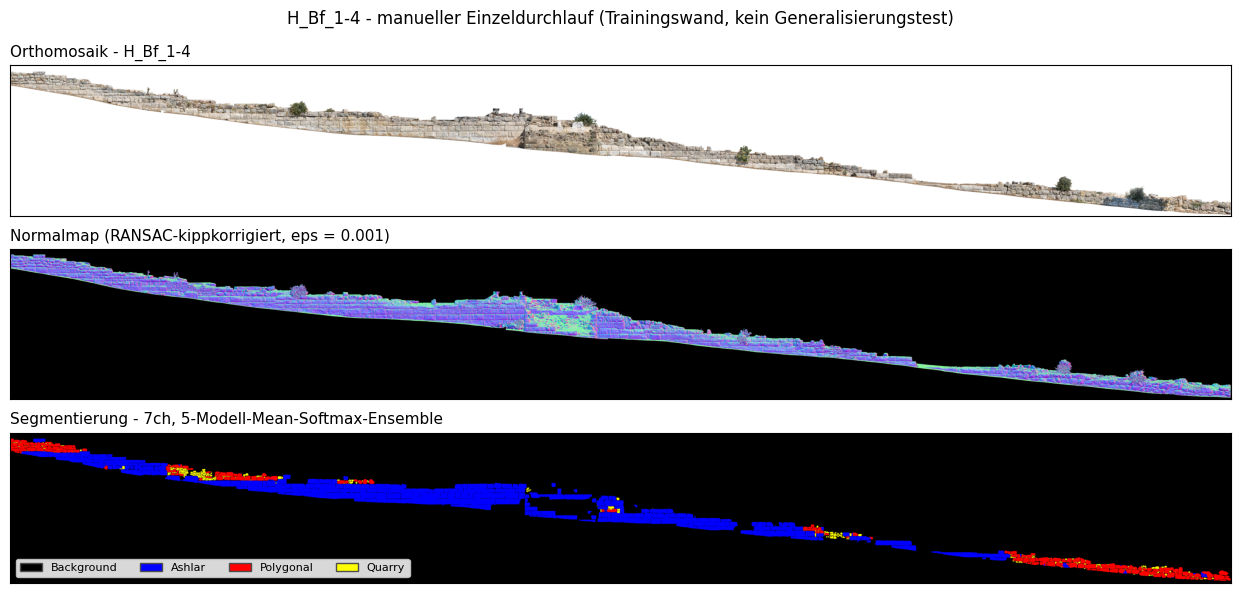

geschrieben: C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\segmentation\overview.png


In [11]:
# --- Uebersichtsabbildung: Ortho, Normalmap (RANSAC), Segmentierung -----------
_t0 = time.time()

k = max(1, math.ceil(W / OVERVIEW_MAX_WIDTH))
target = (max(1, W // k), max(1, H // k))
print(f"Uebersicht: Faktor 1/{k}  ->  {target[0]} x {target[1]} px")

ortho_small  = cv2.resize(cv2.cvtColor(ortho[:, :, :3], cv2.COLOR_BGR2RGB), target,
                          interpolation=cv2.INTER_AREA)
normal_small = cv2.resize(normal_rgb, target, interpolation=cv2.INTER_AREA)
seg_small    = cv2.resize(colored, target, interpolation=cv2.INTER_NEAREST)

panel_h = max(1.6, 12.0 * target[1] / target[0])
fig, axes = plt.subplots(3, 1, figsize=(14, 3 * panel_h + 1.2))
for ax, img, title in zip(
        axes,
        [ortho_small, normal_small, seg_small],
        [f"Orthomosaik - {WALL_NAME}",
         "Normalmap (RANSAC-kippkorrigiert, eps = 0.001)",
         "Segmentierung - 7ch, 5-Modell-Mean-Softmax-Ensemble"]):
    ax.imshow(img)
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_xticks([]); ax.set_yticks([])

legend = [plt.Rectangle((0, 0), 1, 1, fc=np.array(c) / 255.0, ec="0.3")
          for c in CLASS_COLORS_RGB]
axes[2].legend(legend, CLASS_NAMES, loc="lower left", ncol=4, fontsize=8, framealpha=0.85)

fig.suptitle(f"{WALL_NAME} - manueller Einzeldurchlauf (Trainingswand, kein Generalisierungstest)",
             fontsize=12)
fig.tight_layout()
overview_path = OUT_DIR / "overview.png"
fig.savefig(overview_path, dpi=150, bbox_inches="tight")
plt.show()
print("geschrieben:", overview_path)

del ortho_small, normal_small, seg_small
gc.collect()
_timings["06_uebersicht"] = time.time() - _t0

In [12]:
# --- Provenienz ---------------------------------------------------------------
L = []
A = L.append

A("=" * 78)
A("Manueller Einzelwand-Durchlauf - Provenienz")
A("=" * 78)
A(f"Notebook      : 04_segmentation_evaluation/manual_single_wall_segmentation.ipynb")
A(f"Wand          : {WALL_NAME}")
A(f"Start         : {_run_started.isoformat(timespec='seconds')}")
A(f"Ende          : {datetime.datetime.now().isoformat(timespec='seconds')}")
A(f"Rechner       : {platform.node()} | {platform.platform()}")
A(f"Geraet        : {DEVICE}" + (f" | {torch.cuda.get_device_name(0)}" if DEVICE.type == "cuda" else ""))
A(f"Python {platform.python_version()} | torch {torch.__version__} | "
  f"numpy {np.__version__} | OpenCV {cv2.__version__} | rasterio {rasterio.__version__}")
A("")
A("WARNUNG: H_Bf_1-4 gehoert zu den TRAININGSDATEN des Papers. Die Testwaende waren")
A("H_Bf_5, K_Bf_13a, K_Bf_22 und Kaunos_Isodom. Ein Vergleich mit der Ground Truth auf")
A("dieser Wand misst Fit, nicht Generalisierung, und darf nicht neben den Paper-Metriken")
A("stehen.")
A("")
A("-" * 78)
A("EINGABEN")
A("-" * 78)
A(f"DEM           : {DEM_PATH}")
A(f"Ortho         : {ORTHO_PATH}")
A(f"Ausgabeordner : {OUT_DIR}")
A(f"Vollraster    : {W_FULL} x {H_FULL} px")
A(f"CROP          : {CROP}  ->  bearbeitet {W} x {H} px")
A(f"Pixelgroesse  : {PIXEL_SIZE_M!r} m")
A(f"Transform out : {tuple(OUT_TRANSFORM[:6])}")
A(f"CRS           : nicht geschrieben (DEM traegt intern EPSG:4978, geozentrisch, falsch)")
A(f"Nodata (DEM)  : {dem_nodata}  (Maske ueber src.dataset_mask() > 0, Wert nie hartkodiert)")
A("")
A("-" * 78)
A("NORMALMAP")
A("-" * 78)
A(f"Formel        : n = (-dz/dx, +dz/dy, nz), danach normalisiert (Mikkelsen)")
A(f"NZ_MODE       : {NZ_MODE}")
A(f"NZ_EPS        : {NZ_EPS}   ->  nz = {NZ_VALUE}")
A(f"Blockgroesse  : {BLOCK_ROWS} Zeilen, 1 Zeile Halo fuer np.gradient")
A(f"Wandpixel     : {n_wall_total:,} von {H * W:,}")
A("")
A(f"RANSAC        : Fit auf Zufallsstichprobe von {RANSAC_SAMPLE_PIXELS:,} Wandpixeln")
A(f"                (p_keep = {p_keep:.6f}, Seed = {RANSAC_SEED}).")
A("                ABWEICHUNG vom Original: dort werden die Inlier ueber ALLE Wandpixel")
A("                gezaehlt. Bei dieser Wandgroesse waere das nicht rechenbar. Der")
A("                Parameter n_samples je Hypothese liegt mit der Stichprobe auf")
A("                demselben Cap (RANSAC_MAX_SAMPLES) wie im Original.")
A(f"                Hypothesen {RANSAC_N_HYPOTHESES}, Schwelle {RANSAC_THRESHOLD_DEG} Grad, "
  f"LO-Iterationen {RANSAC_REFINE_ITERS}")
A(f"                n_samples je Hypothese : {ransac_diag['n_samples_per_hypothesis']}")
A(f"                Inlier                 : {ransac_diag['final_inlier_pct']:.2f} %")
A(f"                mittlere Wandnormale   : ({mean_normal[0]:+.6f}, {mean_normal[1]:+.6f}, {mean_normal[2]:+.6f})")
A(f"                Abweichung zu (0,0,1)  : {deviation_deg:.4f} Grad -> korrigiert")
A("")
A("-" * 78)
A("MODELL UND INFERENZ")
A("-" * 78)
A(f"Kanaele       : {CHANNELS}  -> Stackreihenfolge [B, G, R, A, nz, ny, nx]")
A(f"Klassen       : {N_CLASSES} {CLASS_NAMES}")
A(f"Ensemble      : {len(models)} Modelle, Mean-Softmax je Fenster, danach center-weighted Merge")
A(f"Quelle        : {SOURCE_EXPERIMENT} / {CHECKPOINT_FILENAME} (Final-Epoch, nicht model_best.pth)")
for p in ckpt_paths:
    st = p.stat()
    A(f"  {p}")
    A(f"    sha256 {sha256_of(p)}  |  {st.st_size:,} B  |  "
      f"mtime {datetime.datetime.fromtimestamp(st.st_mtime).isoformat(timespec='seconds')}")
A("")
A(f"window_size   : {WINDOW_SIZE}")
A(f"stride        : {STRIDE}")
A(f"model_size    : {MODEL_SIZE}   (Downscale INTER_AREA, Rueckskalierung INTER_LINEAR)")
A(f"Fenstergitter : {n_cols} x {n_rows} = {len(positions)}")
A(f"gerechnet     : {n_computed}")
A(f"uebersprungen : {n_skipped}  (SKIP_EMPTY_WINDOWS = {SKIP_EMPTY_WINDOWS}; "
  f"dort Gewicht 0 -> argmax = 0 = Background, keine Modellentscheidung)")
A(f"Akkumulator   : {'np.memmap auf Platte' if use_memmap else 'float32 im RAM'}")
A("")
A("-" * 78)
A("ERGEBNIS")
A("-" * 78)
for i, name in enumerate(CLASS_NAMES):
    A(f"  {i} {name:<11} {int(counts[i]):>14,} px  {100.0 * counts[i] / segmentation.size:6.2f} % vom Bild")
A("")
A("-" * 78)
A("LAUFZEITEN")
A("-" * 78)
for key in sorted(_timings):
    A(f"  {key:<18} {_timings[key] / 60:8.2f} min")
A(f"  {'SUMME':<18} {sum(_timings.values()) / 60:8.2f} min")
A("")
A("-" * 78)
A("AUSGABEN")
A("-" * 78)
for f in sorted(OUT_DIR.iterdir()):
    if f.is_file():
        A(f"  {f.name:<45} {f.stat().st_size:>16,} B")
A("")
A("HINWEIS: unter experiments/ wurde nichts veraendert; es wurden ausschliesslich die")
A("Checkpoints gelesen.")

params_path = OUT_DIR / "run_parameters.txt"
params_path.write_text(chr(10).join(L), encoding="utf-8")
print(chr(10).join(L))
print()
print("geschrieben:", params_path)

Manueller Einzelwand-Durchlauf - Provenienz
Notebook      : 04_segmentation_evaluation/manual_single_wall_segmentation.ipynb
Wand          : H_Bf_1-4
Start         : 2026-07-30T17:45:28
Ende          : 2026-07-30T17:50:31
Rechner       : UDS54537 | Windows-10-10.0.26200-SP0
Geraet        : cuda | NVIDIA GeForce RTX 5080
Python 3.11.9 | torch 2.9.0.dev20250721+cu128 | numpy 2.2.6 | OpenCV 4.12.0 | rasterio 1.4.3

WARNUNG: H_Bf_1-4 gehoert zu den TRAININGSDATEN des Papers. Die Testwaende waren
H_Bf_5, K_Bf_13a, K_Bf_22 und Kaunos_Isodom. Ein Vergleich mit der Ground Truth auf
dieser Wand misst Fit, nicht Generalisierung, und darf nicht neben den Paper-Metriken
stehen.

------------------------------------------------------------------------------
EINGABEN
------------------------------------------------------------------------------
DEM           : C:\Users\admin\Desktop\StatisticalExperiments\v1_baseData\dem\H_Bf_1-4_DEM.tif
Ortho         : C:\Users\admin\Desktop\StatisticalExperiments\